In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Retail Sales and Weather Insights - Sales Dashboard (Pandas + Matplotlib)
#Load Data
df = pd.read_csv('sales_weather.csv')
print('rows,cols',df.shape)
print(df.head())

rows,cols (30, 9)
         Date    Store Product  CustomerID Region  Units_Sold  Price Weather  \
0  2021-01-05  Store_A   Bread        1001  North          20    2.5   Sunny   
1  2021-01-06  Store_A    Milk        1002  North          12    1.8  Cloudy   
2  2021-01-07  Store_A    Eggs        1003  North          30    3.2   Sunny   
3  2021-01-12  Store_A   Bread        1004  North          18    2.5   Sunny   
4  2021-01-15  Store_A    Milk        1001  North          10    1.8   Rainy   

   Temperature  
0           15  
1           12  
2           16  
3           17  
4           11  


In [3]:
#Clean data
df['Date'] = pd.to_datetime(df['Date'])
df['Units_Sold'] = pd.to_numeric(df['Units_Sold'],errors='coerce')
df['Price'] = pd.to_numeric(df['Price'],errors='coerce')
df['Temperature'] = pd.to_numeric(df['Temperature'],errors='coerce')

In [ ]:
#Check for MIssing values and fill values 
print("Missing values before fill",df.isnull().sum())
df['Units_Sold'].fillna(df['Units_Sold'].mean(),inplace=True)
df['Price'].fillna(df['Price'].median(),inplace=True)
df['Weather'].fillna(df['Weather'].mode()[0],inplace=True)
df['Temperature'].fillna(df['Temperature'].mean(),inplace=True)
print("Missing values after filling:",df.isnull().sum())

In [5]:
#Feature Engineering
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['Revenue'] = df['Units_Sold'] * df['Price']

In [6]:
#Save this cleaned csv file
# df.to_csv("Sales_weather_Cleaned.csv",index=False)
# print("\nSaved cleaned CSV -> sales_weather_cleaned.csv")

In [8]:
#EDA aggregates
yearly_revenue = df.groupby('Year')['Revenue'].sum().sort_index()
monthly_revenue = df.groupby('Month')['Revenue'].sum()
product_revenue = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head()
weather_revenue = df.groupby('Weather')['Revenue'].mean()
corr = df[['Units_Sold','Price','Revenue']].corr()
print("\nYearly Revenue: \n",yearly_revenue)
print("\nTop Products: \n",product_revenue)
print("\nTop Customers: \n",top_customers)
print("\nAverage revenue by weather: \n",weather_revenue)
print("\nCorrelation matrix:\n",corr)


Yearly Revenue: 
 Year
2021    3537.7
Name: Revenue, dtype: float64

Top Products: 
 Product
Eggs     2132.1
Bread     907.6
Milk      498.0
Name: Revenue, dtype: float64

Top Customers: 
 CustomerID
1003    600.0
1010    429.6
1001    402.0
1002    341.1
1012    318.0
Name: Revenue, dtype: float64

Average revenue by weather: 
 Weather
Cloudy     63.014286
Rainy      68.000000
Sunny     148.663158
Name: Revenue, dtype: float64

Correlation matrix:
             Units_Sold     Price   Revenue
Units_Sold    1.000000  0.960662  0.989791
Price         0.960662  1.000000  0.954382
Revenue       0.989791  0.954382  1.000000


In [12]:
#Time series and rolling
ts = df.set_index('Date').sort_index()
daily_revenue = ts['Revenue'].resample('D').sum()
monthly_revenue_ts = ts['Revenue'].resample('M').sum()
rolling_7 = ts['Units_Sold'].rolling(window=7,min_periods=1).mean()

C:\Users\User\AppData\Local\Temp\ipykernel_2816\3397920939.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue_ts = ts['Revenue'].resample('M').sum()


In [14]:
import os 
os.makedirs("plots",exist_ok=True)

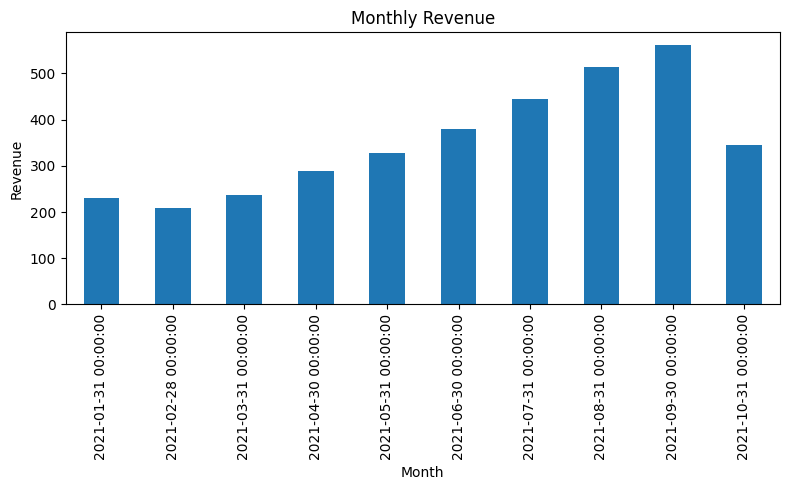

In [17]:
#Plot A
plt.figure(figsize=(8,5))
# plt.bar(monthly_revenue_ts)
monthly_revenue_ts.plot(kind='bar')
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("plots/monthly_revenue.png",dpi=300)
plt.show()

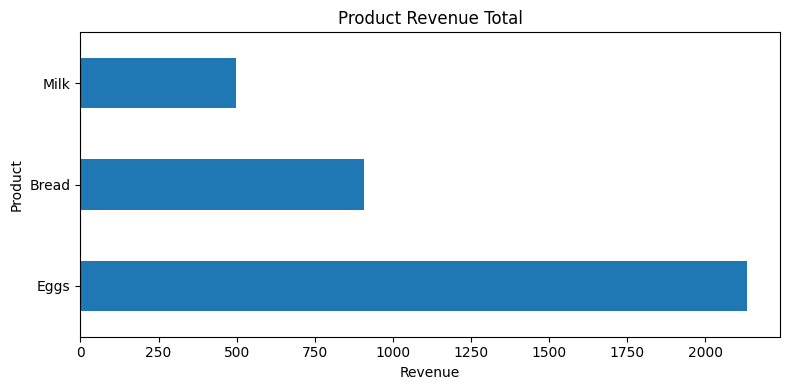

In [18]:
#Plot B: Product Revenue (horizontal bar)
plt.figure(figsize=(8,4))
product_revenue.plot(kind='barh')
plt.title("Product Revenue Total")
plt.xlabel("Revenue")
plt.tight_layout()
plt.savefig("plots/product_revenue.png",dpi=300)
plt.show()

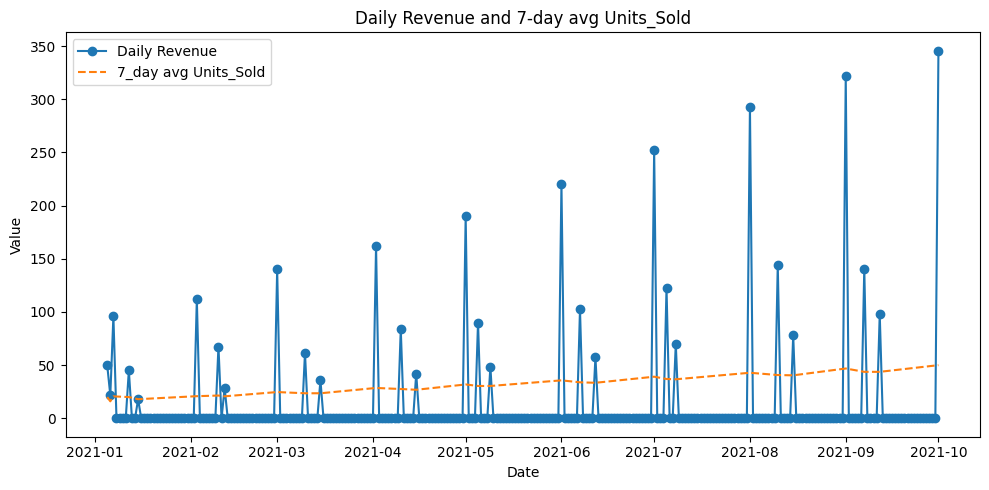

In [19]:
#Plot C: Time Series daily revenue (line) + 7-day rolling units_sold
plt.figure(figsize=(10,5))
plt.plot(daily_revenue.index,daily_revenue.values,label='Daily Revenue',marker='o')
plt.plot(rolling_7.index,rolling_7.values,label='7_day avg Units_Sold',linestyle='--')
plt.legend()
plt.title("Daily Revenue and 7-day avg Units_Sold")
plt.xlabel("Date")
plt.ylabel("Value")
plt.tight_layout()
plt.savefig('plots/daily_revenue_and_rolling.png',dpi=300)
plt.show()

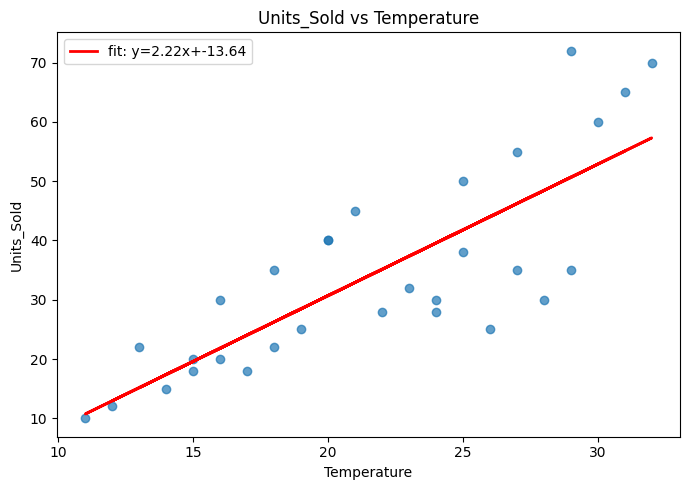

In [20]:
#Plot D: Scatter Units_Sold vs Temperature + simple linear fit
plt.figure(figsize=(7,5))
x = df['Temperature']
y = df['Units_Sold']
plt.scatter(x,y,alpha=0.7)
#linear fit
m, b = np.polyfit(x,y,1)
plt.plot(x,m*x + b,color = 'red',linewidth=2,label=f'fit: y={m:.2f}x+{b:.2f}')
plt.title("Units_Sold vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Units_Sold")
plt.legend()
plt.tight_layout()
plt.savefig("plots/units_vs_temp.png",dpi=300)
plt.show()

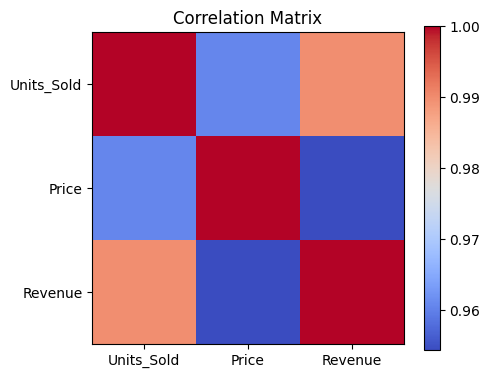

In [21]:
#Plot E:Heatmap of correlation matrix
plt.figure(figsize=(5,4))
plt.imshow(corr,cmap='coolwarm',interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png",dpi=300)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_2816\1232977672.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot,labels=products)


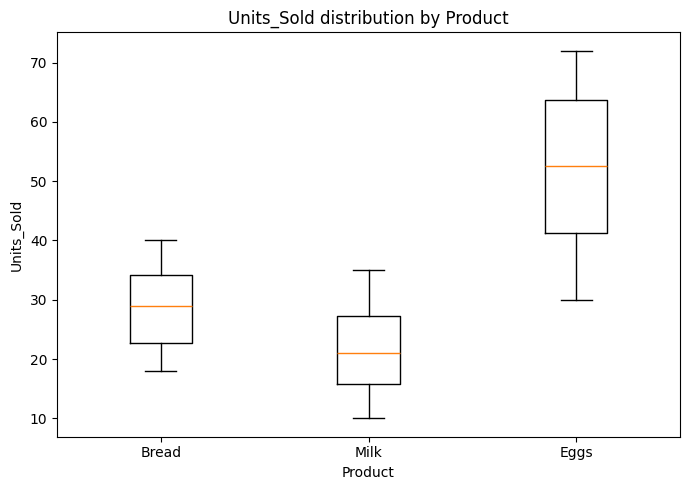

In [23]:
#Plot F: Boxplot Units_Sold by product
plt.figure(figsize=(7,5))
products = df['Product'].unique()
data_to_plot = [df[df['Product']==p]['Units_Sold'] for p in products]
plt.boxplot(data_to_plot,labels=products)
plt.title("Units_Sold distribution by Product")
plt.xlabel("Product")
plt.ylabel("Units_Sold")
plt.tight_layout()
plt.savefig("plots/boxplot_units_by_product.png",dpi=300)
plt.show()

In [26]:
insights = [
    f"Top product by revenue: {product_revenue.idxmax()}",
    f"Top customer by revenue: {top_customers.index[0]}",
    f"Average revenue on sunny days: {weather_revenue.get('Sunny', 0):.2f}",
    f"Best month overall (Year-Month highest revenue): {monthly_revenue.idxmax()}"
]
print("\nInsights:")
for s in insights:
    print("- " + s)


Insights:
- Top product by revenue: Eggs
- Top customer by revenue: 1003
- Average revenue on sunny days: 148.66
- Best month overall (Year-Month highest revenue): 9
